/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_47804/1194331037.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')


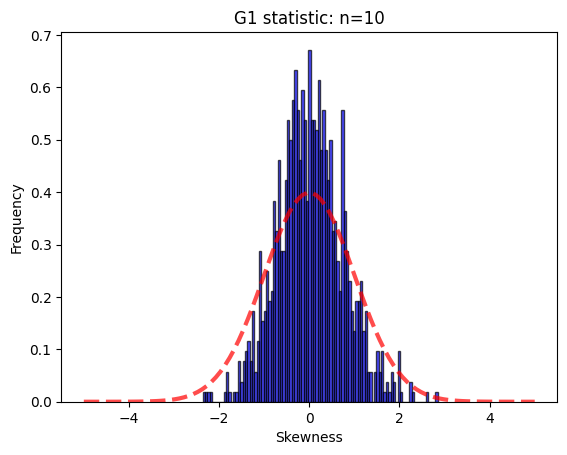

In [23]:
# compute skewness 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import skew, norm



# generate data 
N = 1000
n = 10
x = np.random.normal(0, 1, (N,n))
G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=True)
s = skew(x, axis=1, bias=True)

# plot histogram    
plt.hist(G1, bins=100, color='b', edgecolor='black', alpha=0.7,density=True)
plt.title('G1 statistic: n={}'.format(n))   
plt.xlabel('Skewness')
plt.ylabel('Frequency')
#draw normal distribution
x = np.linspace(-5,5,100)
y = norm.pdf(x,0,1) 
plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red') 
plt.show()



/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_1913/1291389667.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')


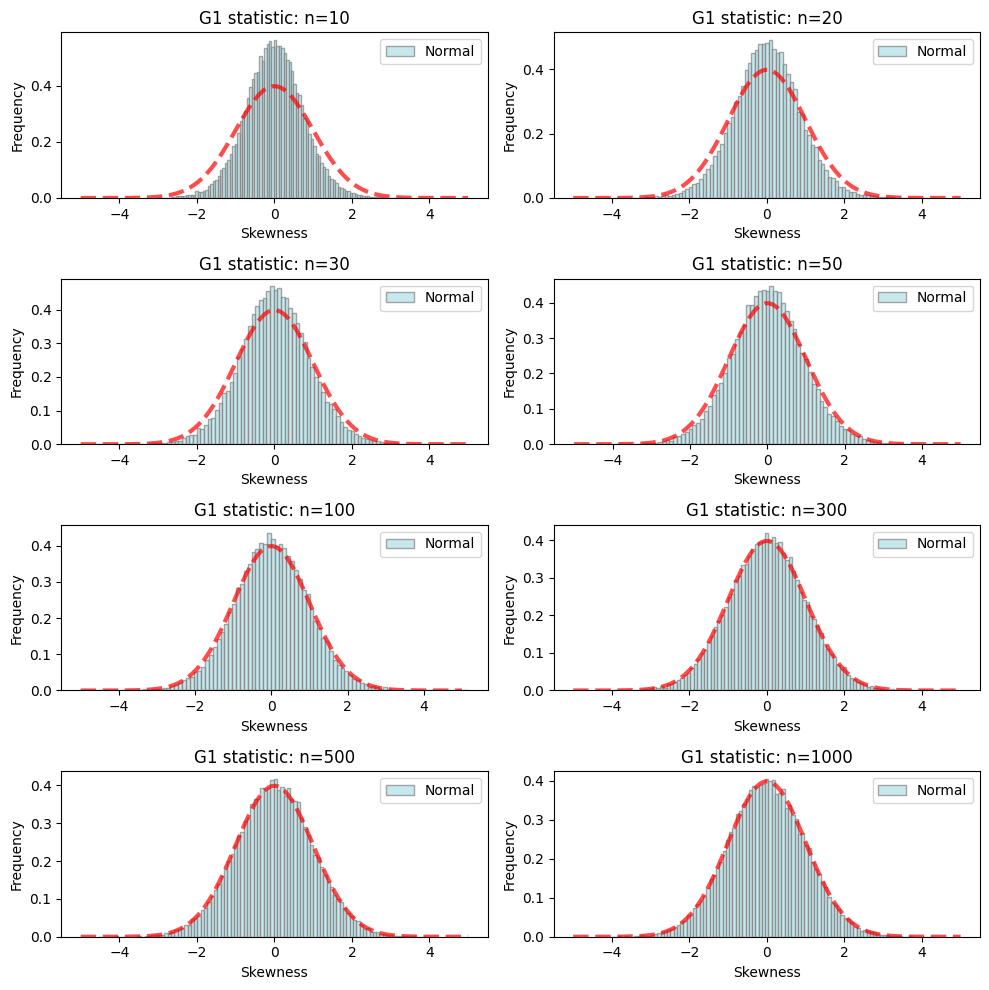

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis    # skewness
from scipy.stats import norm

# generate data from normal distribution for skewness  
N = 50000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] #sample size 
G1 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    G1[:, i] = np.sqrt(n[i] / 6) * skew(x, axis=1, bias=True)

# plot histogram
plt.figure(figsize=(10,10))
for i in range(len(n)):
    plt.subplot(4,2,i+1)
    plt.hist(G1[:,i], bins=100, color= '#B0E0E6', edgecolor='gray', alpha=0.7,density=True)
    plt.title('G1 statistic: n={}'.format(n[i]))   
    plt.xlabel('Skewness')
    plt.ylabel('Frequency')
    plt.legend(['Normal'])  
    #draw normal distribution
    x = np.linspace(-5,5,100)
    y = norm.pdf(x,0,1) 
    plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')
plt.tight_layout()
plt.show()



In [5]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 641.5 kB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


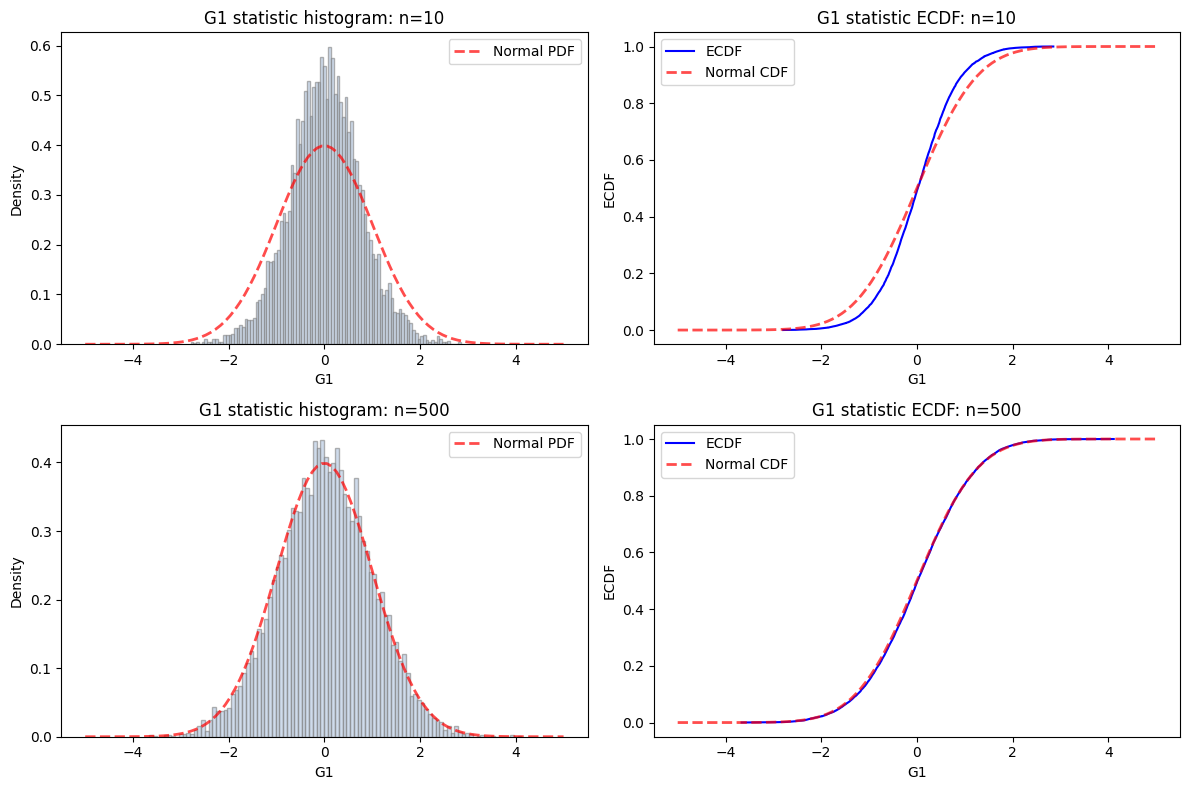

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算偏度
N = 10000  # 重複實驗次數
n_values = [10, 500]  # 樣本大小
G1_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))  # 生成標準正態分佈的數據
    G1 = np.sqrt(n / 6) * skew(x, axis=1, bias=True)  # 計算每個樣本的偏度
    G1_results[n] = G1

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G1 = G1_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G1, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G1 statistic histogram: n={n}')
    ax.set_xlabel('G1')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(-5, 5, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G1)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G1 statistic ECDF: n={n}')
    ax.set_xlabel('G1')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = norm.cdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_1913/576278916.py:26: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')


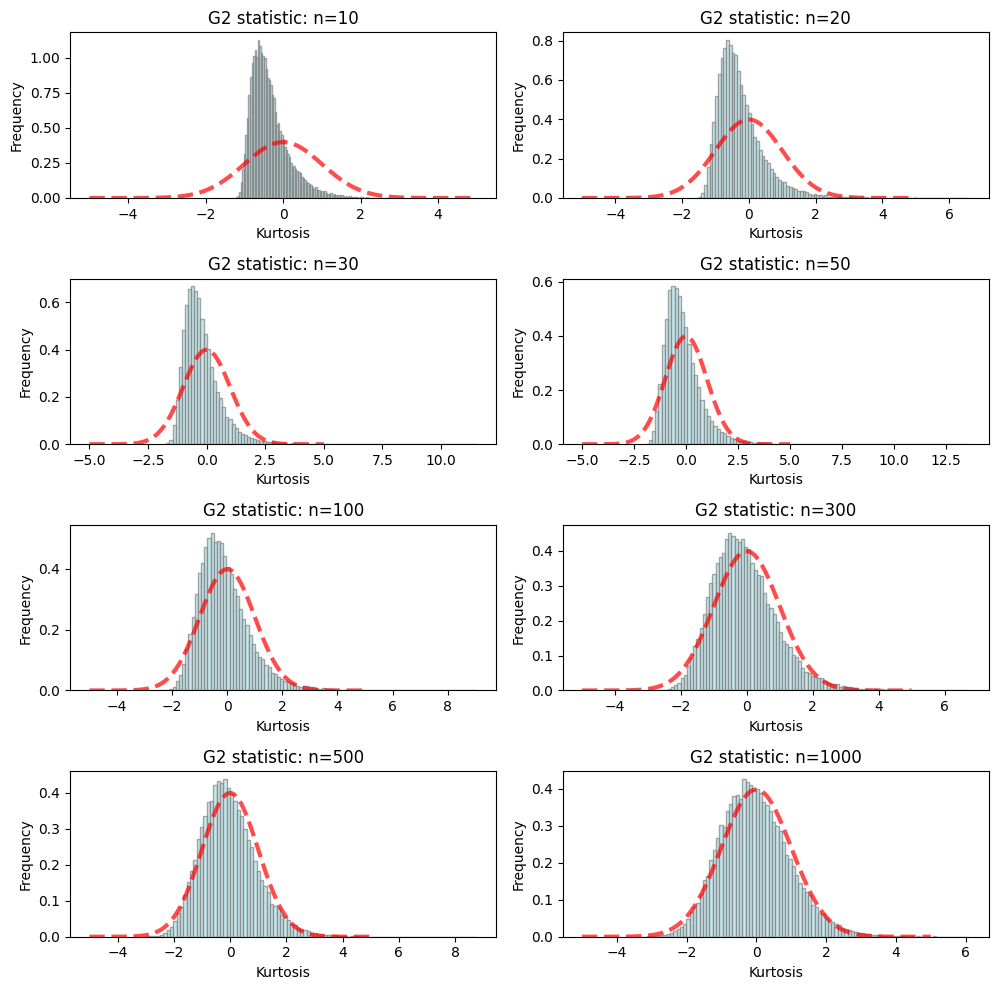

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import norm

# generate data from normal distribution for kurtosis  
N = 50000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] # sample size 
G2 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    G2[:, i] = kurtosis(x, axis=1, bias=True, fisher=True)*np.sqrt(n[i]/24)

# plot histogram
plt.figure(figsize=(10,10))
for i in range(len(n)):
    plt.subplot(4,2,i+1)
    plt.hist(G2[:,i], bins=100, color= '#B0E0E6', edgecolor='gray', alpha=0.7, density=True)
    plt.title('G2 statistic: n={}'.format(n[i]))   
    plt.xlabel('Kurtosis')
    plt.ylabel('Frequency')
    # draw normal distribution
    x = np.linspace(-5,5,100)
    y = norm.pdf(x,0,1) 
    plt.plot(x,y, 'r--', linewidth=3, label='Normal', alpha=0.7, color='red')
plt.tight_layout()
plt.show()

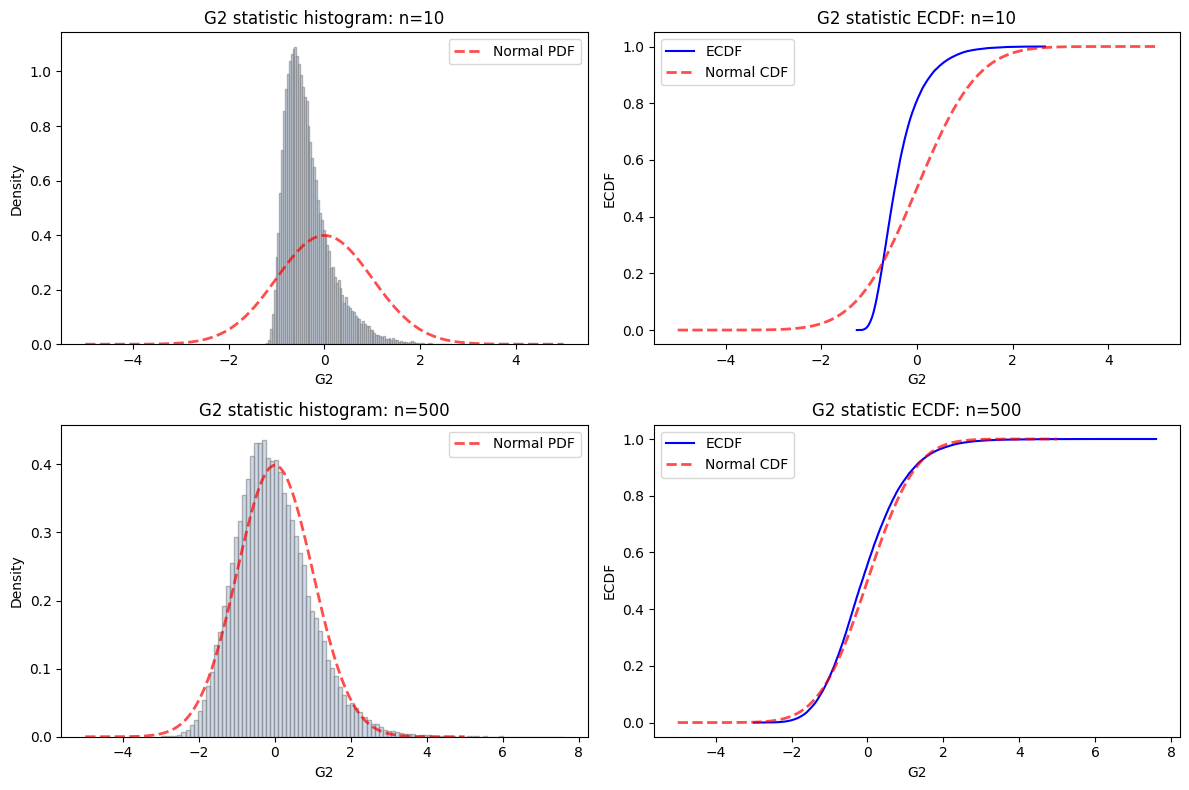

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算峰度
N = 50000  # 重複實驗次數
n_values = [10, 500]  # 樣本大小
G2_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))  # 生成標準正態分佈的數據
    G2 = np.sqrt(n / 24) * (kurtosis(x, axis=1, fisher=True, bias=True))  # 計算每個樣本的峰度
    G2_results[n] = G2

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G2 = G2_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G2, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G2 statistic histogram: n={n}')
    ax.set_xlabel('G2')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(-5, 5, 100)
    y = norm.pdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G2)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G2 statistic ECDF: n={n}')
    ax.set_xlabel('G2')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = norm.cdf(x, 0, 1)
    ax.plot(x, y, 'r--', linewidth=2, label='Normal CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_47804/227931286.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')


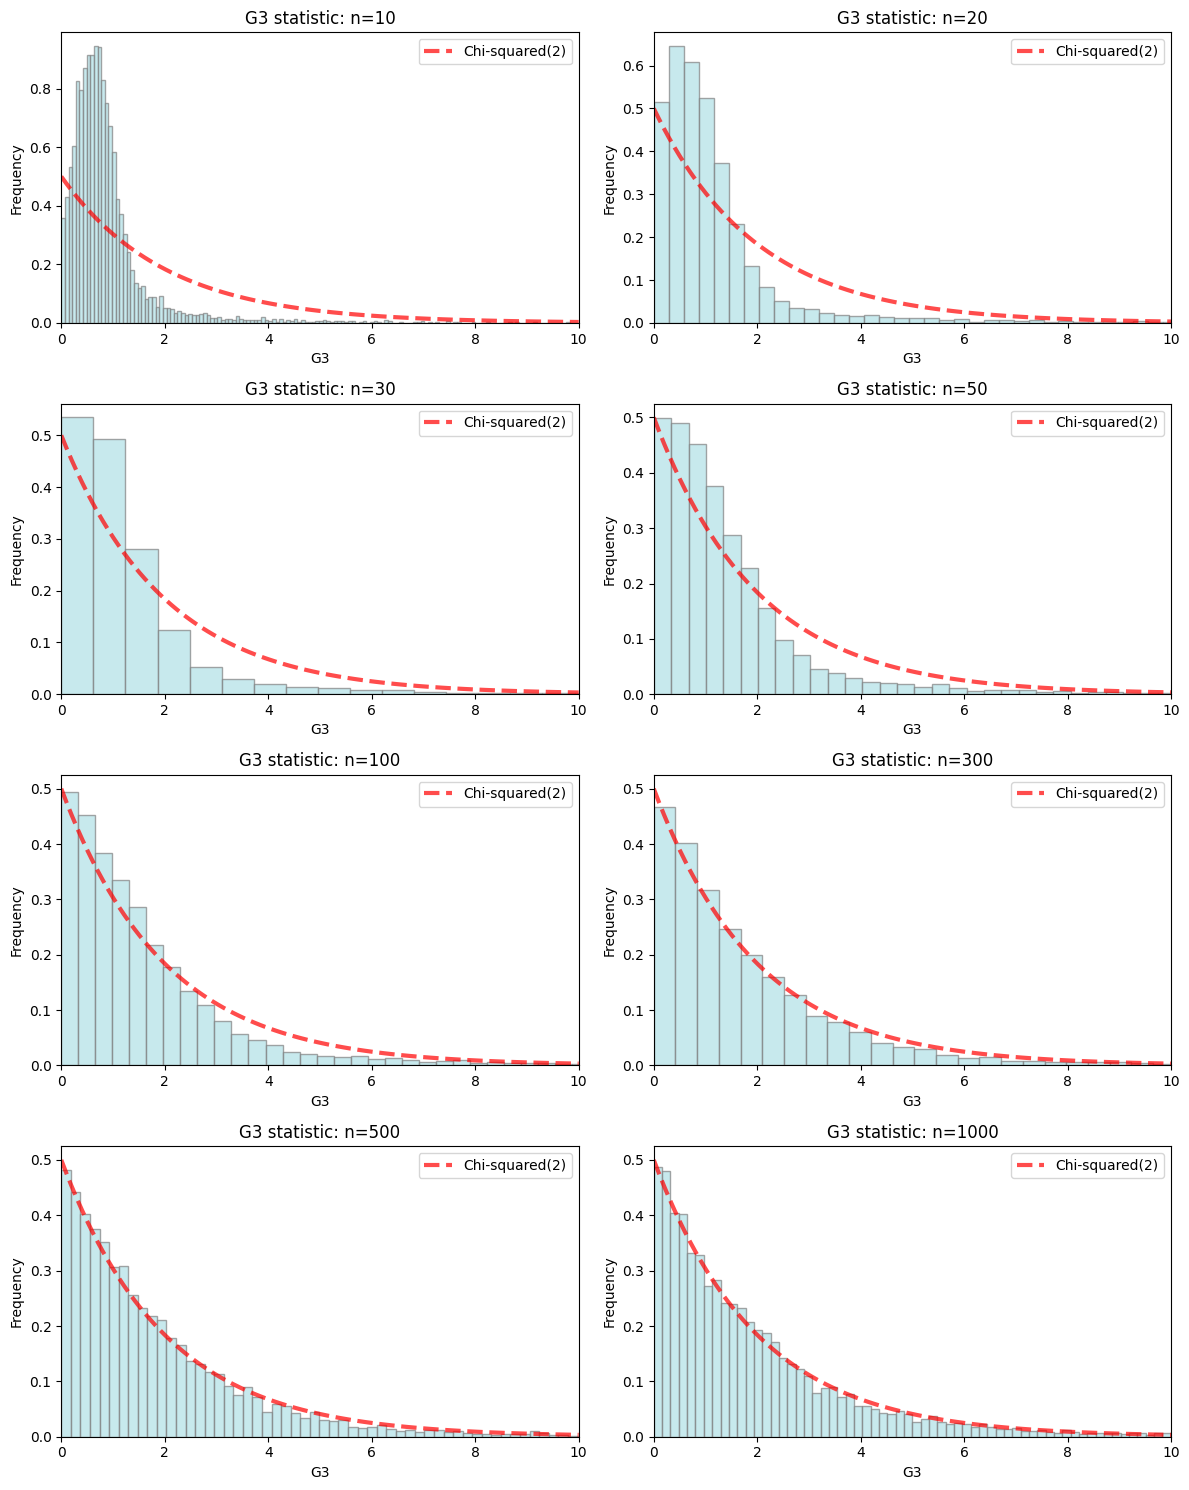

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2

# 生成正態分佈數據以計算偏度和峰度
N = 10000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] # 樣本數
G3 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    s = skew(x, axis=1, bias=True)
    k = kurtosis(x, axis=1, fisher=True, bias=True)
    G1 = np.sqrt(n[i] / 6) * s
    G2 = kurtosis(x, axis=1, bias=True, fisher=True)*np.sqrt(n[i]/24)
    G3[:, i] = G1**2 + G2**2

# 繪製直方圖
fig, axs = plt.subplots(4, 2, figsize=(12, 15))

for i in range(len(n)):
    ax = axs[i // 2, i % 2]
    ax.hist(G3[:,i], bins=200, color= '#B0E0E6', edgecolor='gray', alpha=0.7, density=True)
    ax.set_title('G3 statistic: n={}'.format(n[i]))   
    ax.set_xlabel('G3')
    ax.set_ylabel('Frequency')
    # 繪製卡方分佈
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, df=2) 
    ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')
    ax.legend()
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

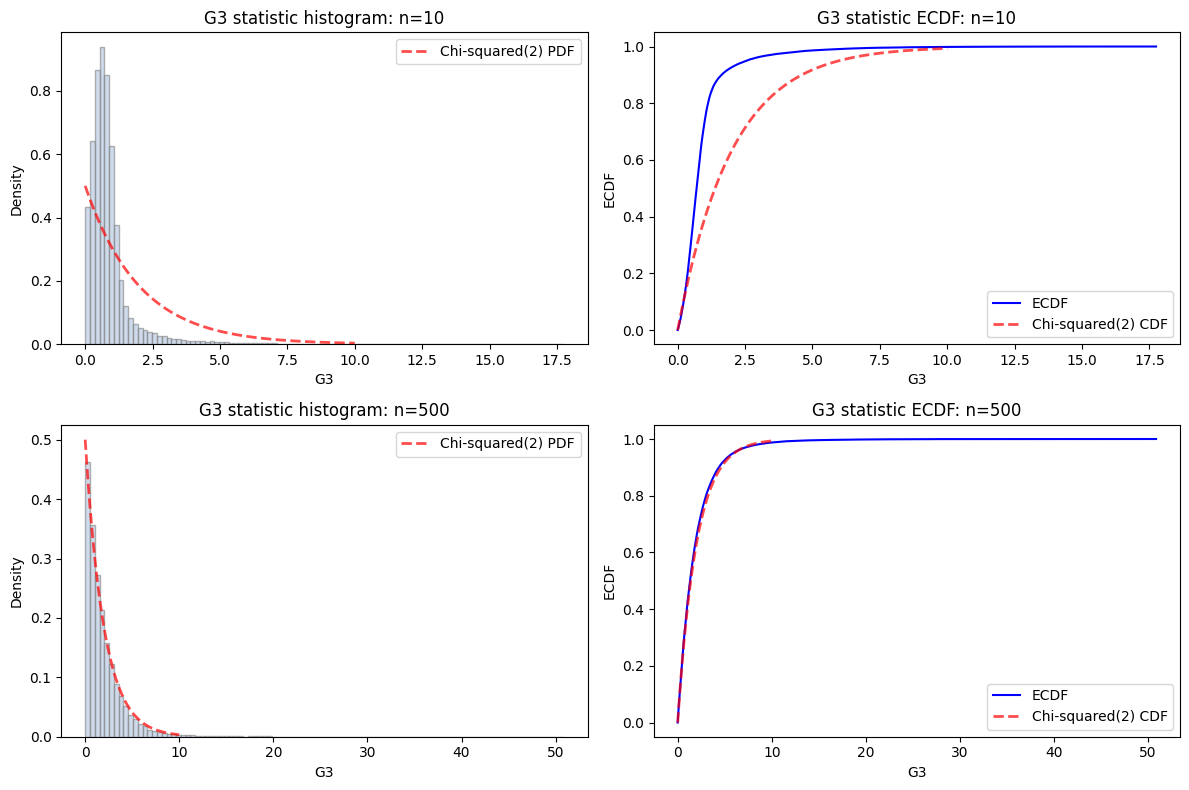

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2, norm
from statsmodels.distributions.empirical_distribution import ECDF

# 生成正態分佈數據以計算偏度和峰度
N = 50000        
n_values = [10, 500]  # 樣本大小
G3_results = {}

for n in n_values:
    x = np.random.normal(0, 1, (N, n))
    s = skew(x, axis=1, bias=True)
    k = kurtosis(x, axis=1, fisher=True, bias=True)
    G1 = np.sqrt(n / 6) * s
    G2 = np.sqrt(n / 24) * (k)
    G3 = G1**2 + G2**2
    G3_results[n] = G3

# 繪製直方圖與標準常態 PDF
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, n in enumerate(n_values):
    G3 = G3_results[n]
    
    # 繪製直方圖
    ax = axs[i, 0]
    ax.hist(G3, bins=100, density=True, alpha=0.6, color='#B0C4DE', edgecolor='gray')
    ax.set_title(f'G3 statistic histogram: n={n}')
    ax.set_xlabel('G3')
    ax.set_ylabel('Density')
    
    # 繪製標準常態 PDF
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, df=2)
    ax.plot(x, y, 'r--', linewidth=2, label='Chi-squared(2) PDF', alpha=0.7)
    ax.legend()
    
    # 繪製 ECDF 圖
    ax = axs[i, 1]
    ecdf = ECDF(G3)
    ax.plot(ecdf.x, ecdf.y, label='ECDF', color='blue')
    ax.set_title(f'G3 statistic ECDF: n={n}')
    ax.set_xlabel('G3')
    ax.set_ylabel('ECDF')
    
    # 繪製標準常態 CDF
    y = chi2.cdf(x, df=2)
    ax.plot(x, y, 'r--', linewidth=2, label='Chi-squared(2) CDF', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/2m/4ztlb_p94yz21fypbmv8lvcr0000gn/T/ipykernel_47804/421323253.py:30: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')


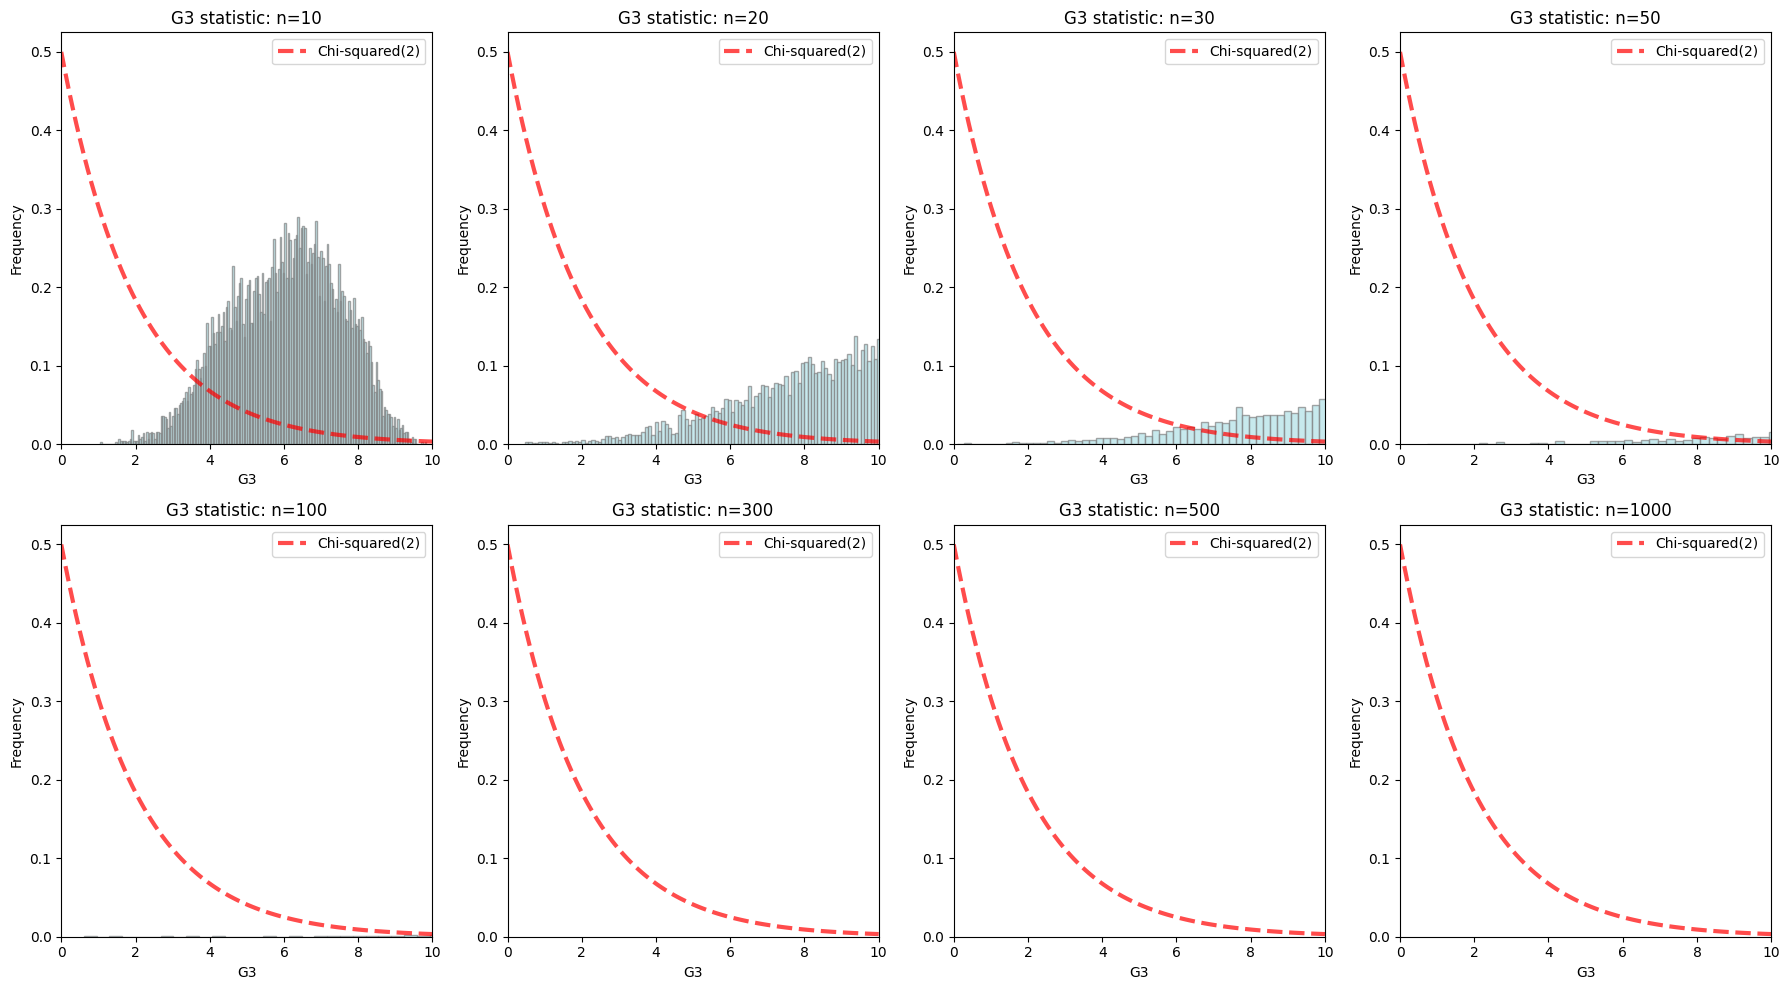

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, chi2

# 生成正態分佈數據以計算偏度和峰度
N = 10000        
n = [10, 20, 30, 50, 100, 300, 500, 1000] # 樣本數
G3 = np.zeros((N, len(n)))

for i in range(len(n)):
    x = np.random.normal(0, 1, (N, n[i]))
    s = skew(x, axis=1, bias=True)
    k = kurtosis(x, axis=1, fisher=True, bias=True)
    G1 = np.sqrt(n[i] / 6) * s
    G2 = np.sqrt(n[i] / 24) * (k - 3)
    G3[:, i] = G1**2 + G2**2

# 繪製直方圖
fig, axs = plt.subplots(2, 4, figsize=(18, 10))  # 調整圖表大小比例

for i in range(len(n)):
    ax = axs[i // 4, i % 4]
    ax.hist(G3[:,i], bins=200, color= '#B0E0E6', edgecolor='gray', alpha=0.7, density=True)
    ax.set_title('G3 statistic: n={}'.format(n[i]))   
    ax.set_xlabel('G3')
    ax.set_ylabel('Frequency')
    # 繪製卡方分佈
    x = np.linspace(0, 10, 100)
    y = chi2.pdf(x, df=2) 
    ax.plot(x, y, 'r--', linewidth=3, label='Chi-squared(2)', alpha=0.7, color='red')
    ax.legend()
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()